In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 8.3 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ps0404","key":"2a6eb4de7030c0bfb89e3f6b1625c3d6"}'}

In [5]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d zhiaun/river-floating-trash-datasets

Dataset URL: https://www.kaggle.com/datasets/zhiaun/river-floating-trash-datasets
License(s): apache-2.0
100% 158M/158M [00:01<00:00, 149MB/s]



In [7]:
!rm -rf /content/dataset
!unzip river-floating-trash-datasets.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/datasets/RFT/images/val/000394.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000431.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000440.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000443.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000456.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000483.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000484.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000485.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000508.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000514.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000521.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000523.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000528.jpg  
  inflating: /content/dataset/datasets/RFT/images/val/000535.jpg  
  inflating

In [8]:
%%writefile /content/data.yaml
path: /content/dataset/datasets/RFT
train: images/train
val: images/val

nc: 8
names: ['bottle','grass','branch','milk-box','plastic-bag','plastic-garbage','ball','leaf']

Writing /content/data.yaml


In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    patience=25,
    fliplr=0.5
)

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimi

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ef928167d20>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [10]:
# Cell 8
model.save("my_model.pt")
print("Model saved successfully!")

Model saved successfully!


In [11]:
from google.colab import files
files.download("runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

In [13]:
metrics = model.val()

Ultralytics 8.4.137 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1456.9±559.7 MB/s, size: 47.4 KB)
val: Scanning /content/dataset/datasets/RFT/labels/val.cache... 239 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 239/239 50.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.4it/s 4.5s
                   all        239        348      0.742      0.712      0.758      0.466
                bottle         99        165      0.885      0.887      0.936      0.624
                 grass         18         18      0.793      0.722      0.766      0.284
                branch         42         42      0.521      0.476      0.479      0.255
              milk-box         25         27      0.759      0.889      0.857      0.601
           plastic-bag         35    

In [14]:
import pandas as pd

classes = metrics.names
cm_np = metrics.confusion_matrix.matrix

metrics_list = []

for i, cls in enumerate(classes):
    TP = cm_np[i, i]
    FP = cm_np[:, i].sum() - TP
    FN = cm_np[i, :].sum() - TP
    TN = cm_np.sum() - (TP + FP + FN)

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)

    metrics_list.append([cls, TP, TN, FP, FN,
                         precision, recall, specificity, f1_score])

metrics_df = pd.DataFrame(metrics_list,
    columns=["Class","TP","TN","FP","FN",
             "Precision","Recall","Specificity","F1 Score"])

print("\nDETAILED METRICS:\n")
print(metrics_df)


DETAILED METRICS:

   Class     TP     TN    FP    FN  Precision    Recall  Specificity  F1 Score
0      0  155.0  303.0  10.0  24.0   0.939394  0.865922     0.968051  0.901162
1      1   15.0  455.0   3.0  19.0   0.833333  0.441176     0.993450  0.576923
2      2   30.0  406.0  12.0  44.0   0.714286  0.405405     0.971292  0.517241
3      3   24.0  453.0   3.0  12.0   0.888889  0.666667     0.993421  0.761904
4      4   29.0  432.0   8.0  23.0   0.783784  0.557692     0.981818  0.651685
5      5   15.0  462.0   3.0  12.0   0.833333  0.555556     0.993548  0.666666
6      6    6.0  481.0   4.0   1.0   0.600000  0.857143     0.991753  0.705882
7      7   21.0  445.0  10.0  16.0   0.677419  0.567568     0.978022  0.617647


In [15]:
# Cell 10
import numpy as np
import pandas as pd

if 'metrics' in locals() and hasattr(metrics, 'confusion_matrix') and hasattr(metrics.confusion_matrix, 'matrix'):
    cm = metrics.confusion_matrix.matrix
else:
    print("Error: metrics not found. Run model.val() first.")
    cm = None

if cm is not None:
    classes = ['bottle','grass','branch','milk-box','plastic-bag',
               'plastic-garbage','ball','leaf','background']

    try:
        cm_np = cm.cpu().numpy() if hasattr(cm, 'cpu') else np.array(cm)
        df = pd.DataFrame(cm_np, index=classes, columns=classes)

        print("\nConfusion Matrix:\n")
        print(df)

    except Exception as e:
        print(f"Error converting confusion matrix: {e}")


Confusion Matrix:

                 bottle  grass  branch  milk-box  plastic-bag  \
bottle            155.0    0.0     0.0       0.0          1.0   
grass               0.0   15.0     0.0       0.0          1.0   
branch              0.0    0.0    30.0       0.0          0.0   
milk-box            1.0    0.0     0.0      24.0          0.0   
plastic-bag         0.0    0.0     1.0       1.0         29.0   
plastic-garbage     0.0    0.0     0.0       0.0          0.0   
ball                0.0    0.0     0.0       0.0          0.0   
leaf                0.0    0.0     1.0       0.0          0.0   
background          9.0    3.0    10.0       2.0          6.0   

                 plastic-garbage  ball  leaf  background  
bottle                       0.0   0.0   0.0        23.0  
grass                        0.0   0.0   0.0        18.0  
branch                       0.0   0.0   0.0        44.0  
milk-box                     0.0   0.0   0.0        11.0  
plastic-bag                  1.0  

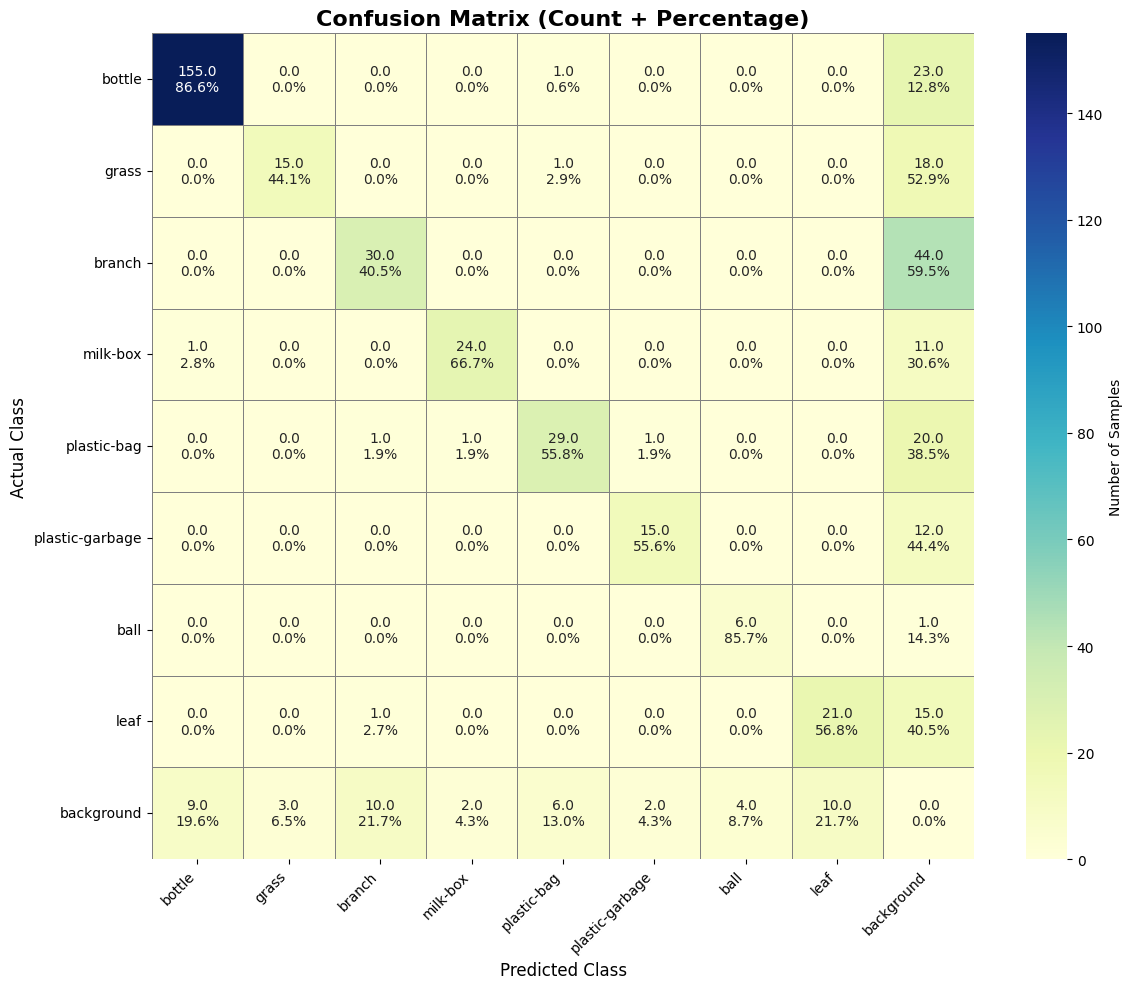

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize confusion matrix (row-wise percentage)
cm_percent = cm_np.astype('float') / cm_np.sum(axis=1)[:, np.newaxis] * 100

# Create labels (count + percentage)
labels = np.empty_like(cm_np).astype(str)

for i in range(cm_np.shape[0]):
    for j in range(cm_np.shape[1]):
        count = cm_np[i, j]
        percent = cm_percent[i, j]
        labels[i, j] = f"{count}\n{percent:.1f}%"

plt.figure(figsize=(12,10))

sns.heatmap(cm_np,
            annot=labels,
            fmt="",
            cmap="YlGnBu",   # ✅ same color you want
            xticklabels=classes,
            yticklabels=classes,
            linewidths=0.5,
            linecolor='gray',
            cbar_kws={'label': 'Number of Samples'})

plt.title("Confusion Matrix (Count + Percentage)", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [17]:
metrics_df["Precision %"] = metrics_df["Precision"] * 100
metrics_df["Recall %"] = metrics_df["Recall"] * 100
metrics_df["Specificity %"] = metrics_df["Specificity"] * 100
metrics_df["F1 Score %"] = metrics_df["F1 Score"] * 100

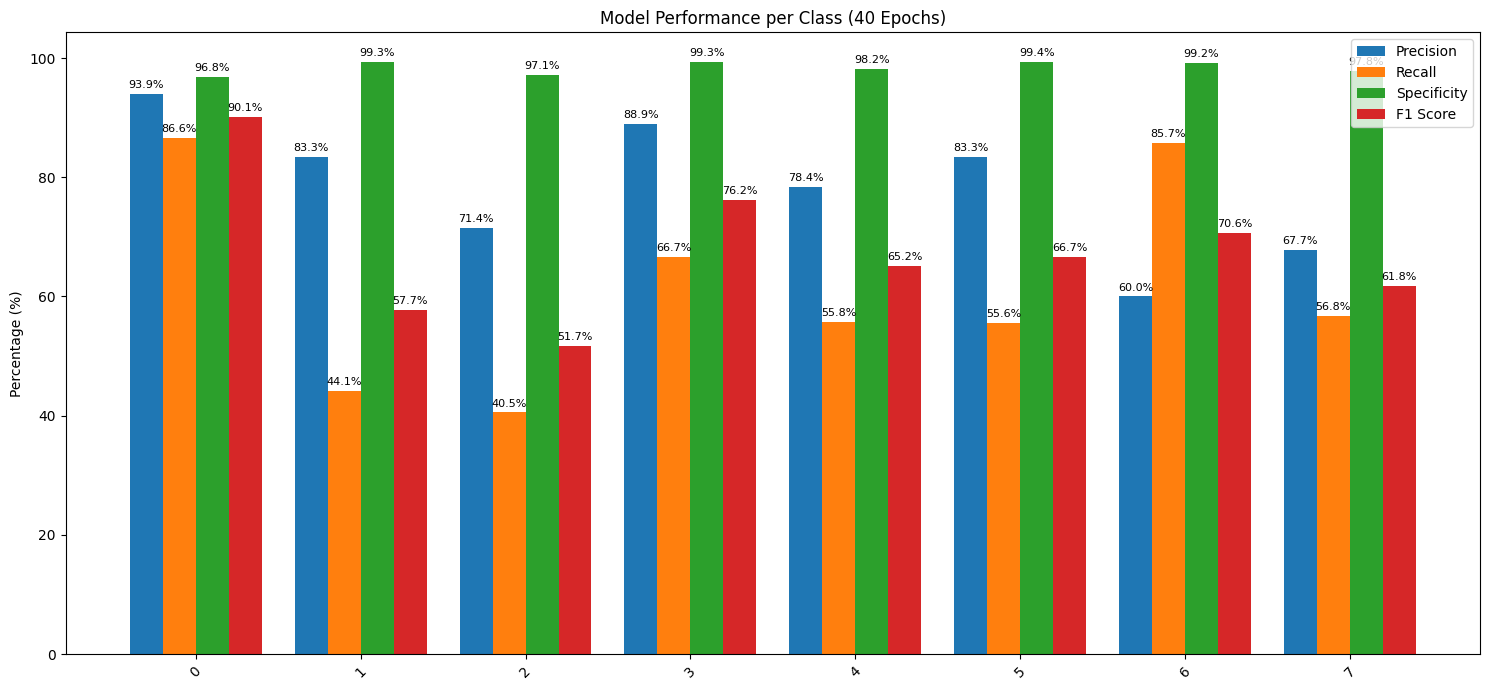

In [18]:
import numpy as np

x = np.arange(len(metrics_df["Class"]))
width = 0.2

plt.figure(figsize=(15,7))

bars1 = plt.bar(x - 1.5*width, metrics_df["Precision %"], width, label='Precision')
bars2 = plt.bar(x - 0.5*width, metrics_df["Recall %"], width, label='Recall')
bars3 = plt.bar(x + 0.5*width, metrics_df["Specificity %"], width, label='Specificity')
bars4 = plt.bar(x + 1.5*width, metrics_df["F1 Score %"], width, label='F1 Score')

# 🔥 Add percentage labels on top
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height + 1,
                 f"{height:.1f}%",
                 ha='center', fontsize=8)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)

plt.xticks(x, metrics_df["Class"], rotation=45)
plt.ylabel("Percentage (%)")
plt.title("Model Performance per Class (40 Epochs)")
plt.legend()

plt.tight_layout()
plt.show()

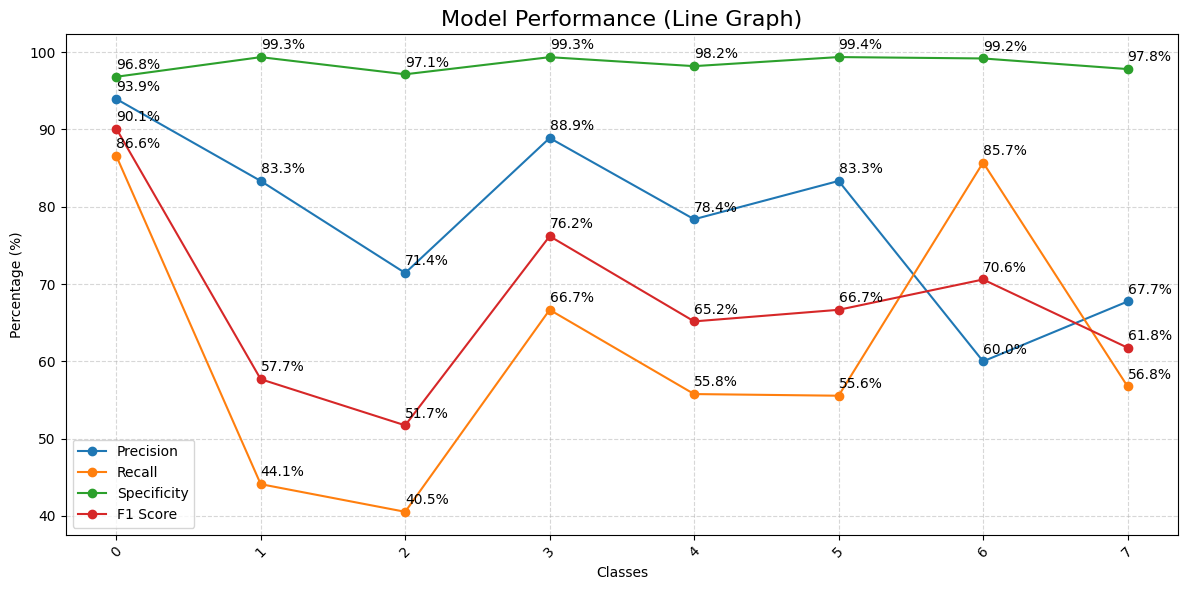

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(metrics_df["Class"], metrics_df["Precision %"], marker='o', label='Precision')
plt.plot(metrics_df["Class"], metrics_df["Recall %"], marker='o', label='Recall')
plt.plot(metrics_df["Class"], metrics_df["Specificity %"], marker='o', label='Specificity')
plt.plot(metrics_df["Class"], metrics_df["F1 Score %"], marker='o', label='F1 Score')

# Add percentage labels
for i in range(len(metrics_df)):
    plt.text(i, metrics_df["Precision %"][i]+1, f'{metrics_df["Precision %"][i]:.1f}%')
    plt.text(i, metrics_df["Recall %"][i]+1, f'{metrics_df["Recall %"][i]:.1f}%')
    plt.text(i, metrics_df["Specificity %"][i]+1, f'{metrics_df["Specificity %"][i]:.1f}%')
    plt.text(i, metrics_df["F1 Score %"][i]+1, f'{metrics_df["F1 Score %"][i]:.1f}%')

plt.title("Model Performance (Line Graph)", fontsize=16)
plt.xlabel("Classes")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
from ultralytics import YOLO
import os
from IPython.display import Image, display

# ✅ Load trained model (after 40 epochs)
model = YOLO("runs/detect/train/weights/best.pt")

# ✅ Run prediction on test images (this draws bounding boxes automatically)
results = model.predict(
    source="/content/dataset/datasets/RFT/images/test",  # your test images path
    conf=0.25,        # confidence threshold (increase for better quality)
    save=True,        # saves images with bounding boxes
    save_txt=False    # set True if you want labels also
)

print("✅ Prediction completed and saved!")


image 1/481 /content/dataset/datasets/RFT/images/test/000006.jpg: 640x640 3 grasss, 10.4ms
image 2/481 /content/dataset/datasets/RFT/images/test/000015.jpg: 640x640 4 branchs, 2 milk-boxs, 7.3ms
image 3/481 /content/dataset/datasets/RFT/images/test/000019.jpg: 640x640 1 milk-box, 3 plastic-bags, 7.2ms
image 4/481 /content/dataset/datasets/RFT/images/test/000022.jpg: 640x640 1 grass, 7.0ms
image 5/481 /content/dataset/datasets/RFT/images/test/000031.jpg: 640x640 2 bottles, 1 plastic-bag, 10.4ms
image 6/481 /content/dataset/datasets/RFT/images/test/000035.jpg: 640x640 1 branch, 7.1ms
image 7/481 /content/dataset/datasets/RFT/images/test/000040.jpg: 640x640 2 grasss, 7.0ms
image 8/481 /content/dataset/datasets/RFT/images/test/000043.jpg: 640x640 2 branchs, 1 milk-box, 7.1ms
image 9/481 /content/dataset/datasets/RFT/images/test/000046.jpg: 640x640 2 branchs, 1 milk-box, 7.0ms
image 10/481 /content/dataset/datasets/RFT/images/test/000072.jpg: 640x640 1 branch, 3 milk-boxs, 1 plastic-garbag

Showing results from: predict


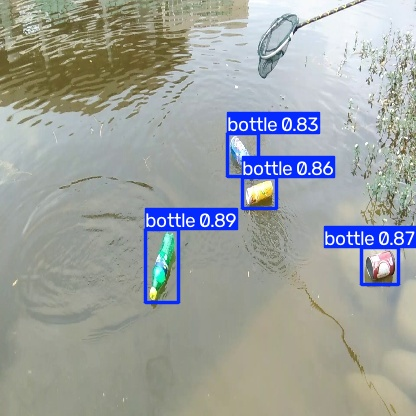

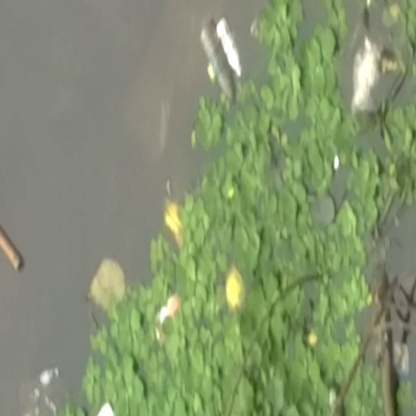

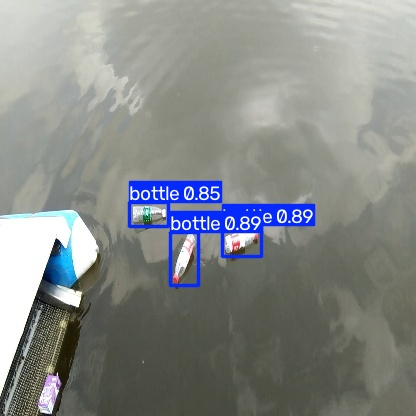

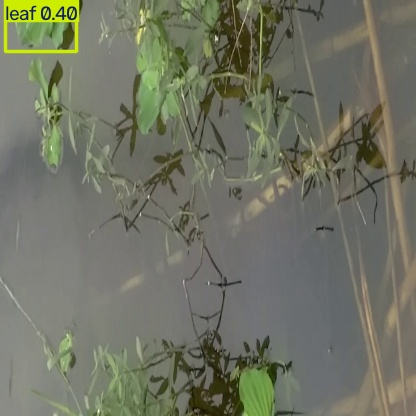

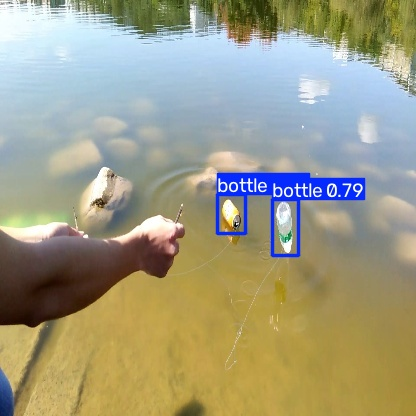

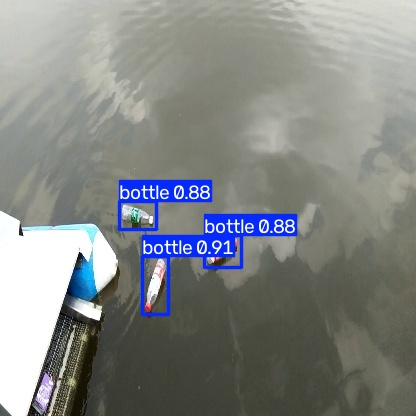

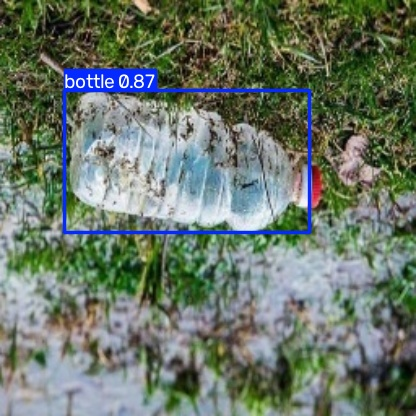

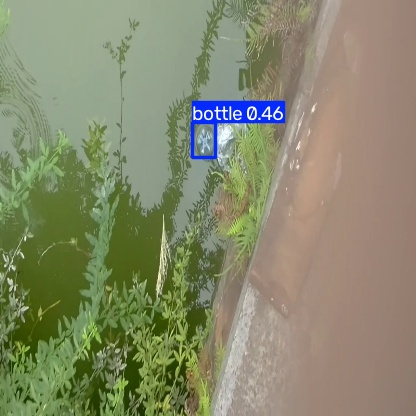

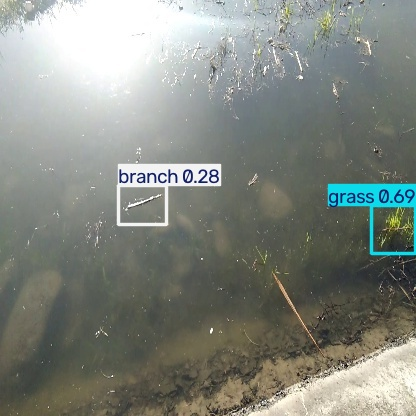

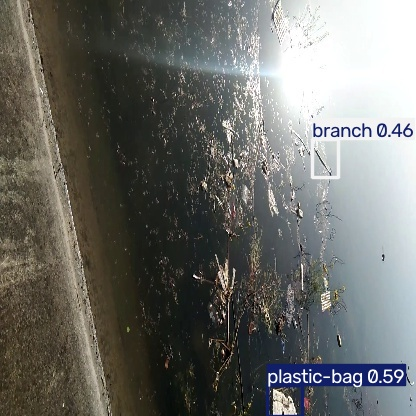

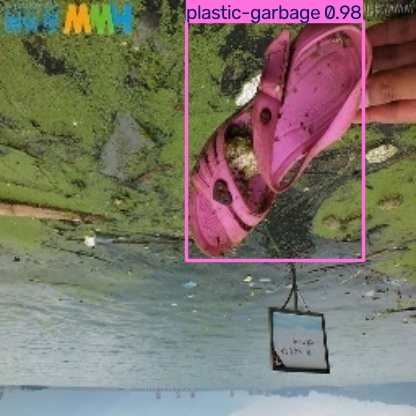

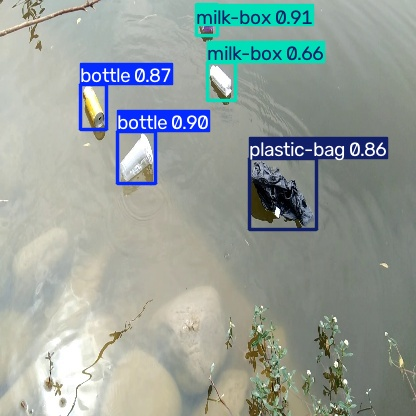

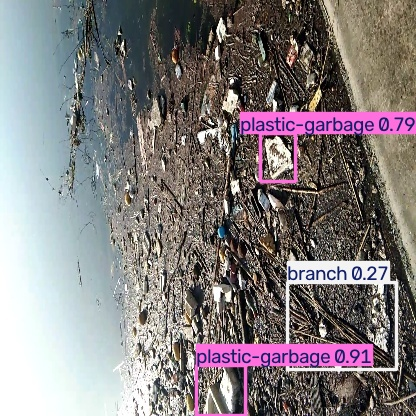

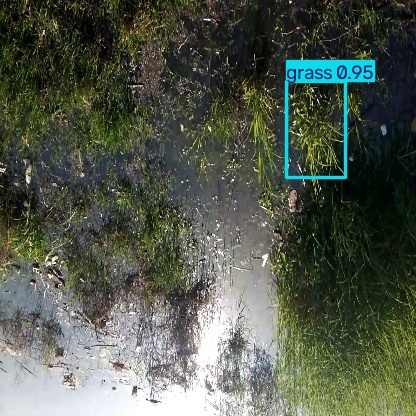

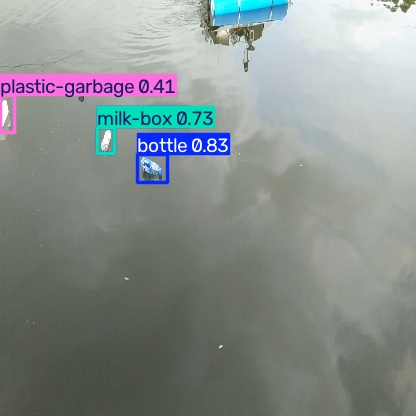

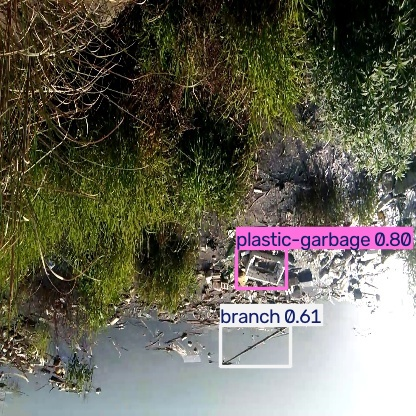

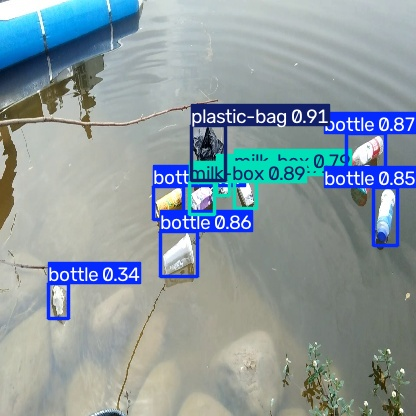

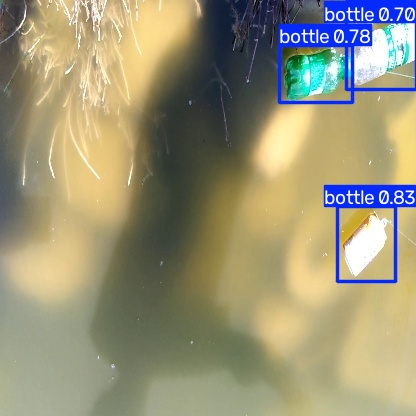

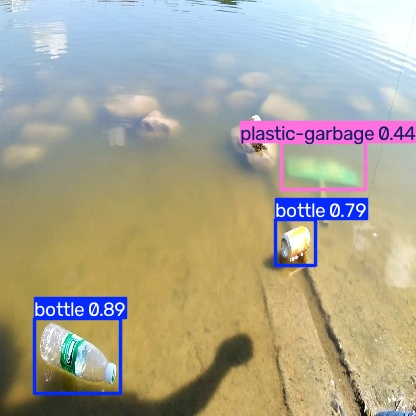

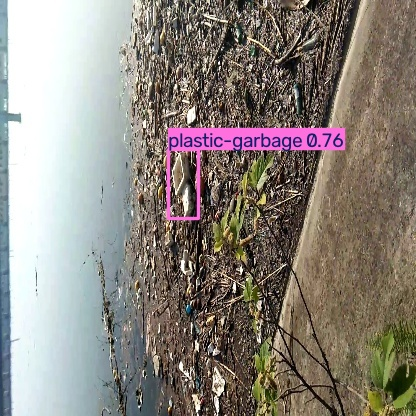

In [21]:
# Path where predictions are saved
base = "runs/detect"

# Find latest predict folder
preds = [f for f in os.listdir(base) if "predict" in f]
latest = sorted(preds)[-1]

print("Showing results from:", latest)

# Show first 10 images
for img in os.listdir(os.path.join(base, latest))[:20]:
    display(Image(os.path.join(base, latest, img)))

In [22]:
from google.colab import files
uploaded = files.upload()   # Upload best.pt here

Saving best (4).pt to best (4).pt


In [25]:
!pip install ultralytics

from ultralytics import YOLO
import os

model = YOLO("best (4).pt")
print("Saved model loaded successfully")

Saved model loaded successfully


In [26]:
import numpy as np
import pandas as pd

# Get confusion matrix
cm = metrics.confusion_matrix.matrix
classes = metrics.names

metrics_list = []

for i, cls in enumerate(classes):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    accuracy = (TP + TN) / (cm.sum() + 1e-6)

    metrics_list.append([cls, precision, recall, f1, accuracy])

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics_list, columns=[
    "Class", "Precision", "Recall", "F1 Score", "Accuracy"
])

# Convert to percentage
metrics_df["Precision %"] = metrics_df["Precision"] * 100
metrics_df["Recall %"] = metrics_df["Recall"] * 100
metrics_df["F1 Score %"] = metrics_df["F1 Score"] * 100
metrics_df["Accuracy %"] = metrics_df["Accuracy"] * 100

print(metrics_df)

   Class  Precision    Recall  F1 Score  Accuracy  Precision %   Recall %  \
0      0   0.939394  0.865922  0.901162  0.930894    93.939393  86.592178   
1      1   0.833333  0.441176  0.576923  0.955285    83.333329  44.117646   
2      2   0.714286  0.405405  0.517241  0.886179    71.428570  40.540540   
3      3   0.888889  0.666667  0.761904  0.969512    88.888886  66.666665   
4      4   0.783784  0.557692  0.651685  0.936992    78.378376  55.769230   
5      5   0.833333  0.555556  0.666666  0.969512    83.333329  55.555553   
6      6   0.600000  0.857143  0.705882  0.989837    59.999994  85.714273   
7      7   0.677419  0.567568  0.617647  0.947154    67.741933  56.756755   

   F1 Score %  Accuracy %  
0   90.116229   93.089431  
1   57.692260   95.528455  
2   51.724091   88.617886  
3   76.190425   96.951219  
4   65.168489   93.699187  
5   66.666616   96.951219  
6   70.588179   98.983740  
7   61.764654   94.715447  


In [27]:
# Overall metrics (average)
overall_precision = metrics_df["Precision"].mean()
overall_recall = metrics_df["Recall"].mean()
overall_f1 = metrics_df["F1 Score"].mean()
overall_accuracy = metrics_df["Accuracy"].mean()

print("\n===== OVERALL MODEL PERFORMANCE =====")
print(f"Precision: {overall_precision*100:.2f}%")
print(f"Recall: {overall_recall*100:.2f}%")
print(f"F1 Score: {overall_f1*100:.2f}%")
print(f"Accuracy (Model Performance): {overall_accuracy*100:.2f}%")


===== OVERALL MODEL PERFORMANCE =====
Precision: 78.38%
Recall: 61.46%
F1 Score: 67.49%
Accuracy (Model Performance): 94.82%


In [28]:
# 🔹 Install
!pip install gradio

import gradio as gr
import sqlite3
import hashlib
from PIL import Image
import numpy as np

# =========================
# 🔍 Load YOLO Model
# =========================
try:
    model
except NameError:
    try:
        model = yolo_model
    except:
        raise Exception("❌ Model not found. Check your model variable name.")

# =========================
# 🗄️ Database Setup
# =========================
conn = sqlite3.connect("users.db", check_same_thread=False)
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    username TEXT PRIMARY KEY,
    password TEXT
)
""")
conn.commit()

# =========================
# 🔐 Password Hash Function
# =========================
def hash_password(password):
    return hashlib.sha256(password.encode()).hexdigest()

# =========================
# 📝 Signup Function
# =========================
def signup(username, password):

    if username == "" or password == "":
        return "⚠️ Please fill all fields"

    cursor.execute("SELECT * FROM users WHERE username=?", (username,))
    existing_user = cursor.fetchone()

    if existing_user:
        return "❌ Username already exists"

    hashed_pwd = hash_password(password)

    cursor.execute(
        "INSERT INTO users VALUES (?, ?)",
        (username, hashed_pwd)
    )

    conn.commit()

    return "✅ Signup Successful"

# =========================
# 🔑 Login Function
# =========================
def login(username, password):

    hashed_pwd = hash_password(password)

    cursor.execute(
        "SELECT * FROM users WHERE username=? AND password=?",
        (username, hashed_pwd)
    )

    user = cursor.fetchone()

    if user:
        return (
            gr.update(visible=True),
            gr.update(visible=False),
            f"✅ Welcome {username}"
        )

    return (
        gr.update(visible=False),
        gr.update(visible=True),
        "❌ Invalid Username or Password"
    )

# =========================
# 🚪 Logout Function
# =========================
def logout():
    return (
        gr.update(visible=False),
        gr.update(visible=True),
        "👋 Logged Out Successfully"
    )

# =========================
# 🔍 Detection Function
# =========================
def predict_image(image):

    img = Image.fromarray(image)

    results = model(img)

    output_img = results[0].plot()

    labels = []

    try:
        boxes = results[0].boxes

        for box in boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])

            name = model.names[cls]

            labels.append(f"{name} ({conf:.2f})")

    except:
        labels.append("No objects detected")

    label_text = "\n".join(labels)

    return output_img, label_text

# =========================
# 🎨 Custom CSS
# =========================
custom_css = """
body {
    background-color: #e6f2ff;
}

.gradio-container {
    background-color: #e6f2ff !important;
}

h1, h2, p {
    color: #003366 !important;
}

button {
    background-color: #3399ff !important;
    color: white !important;
    border-radius: 10px !important;
    font-size: 16px !important;
}

textarea, input {
    border-radius: 8px !important;
}
"""

# =========================
# 🚀 UI
# =========================
with gr.Blocks(css=custom_css) as demo:

    gr.Markdown("# 🌊 River Trash Detection System")

    # =====================
    # AUTH SECTION
    # =====================
    with gr.Column(visible=True) as auth_section:

        with gr.Tab("🔑 Login"):

            login_user = gr.Textbox(label="Username")
            login_pass = gr.Textbox(
                label="Password",
                type="password"
            )

            login_btn = gr.Button("Login")

        with gr.Tab("📝 Sign Up"):

            signup_user = gr.Textbox(label="Create Username")

            signup_pass = gr.Textbox(
                label="Create Password",
                type="password"
            )

            signup_btn = gr.Button("Sign Up")

        auth_status = gr.Textbox(label="Status")

    # =====================
    # MAIN APP
    # =====================
    with gr.Column(visible=False) as main_app:

        gr.Markdown("## ♻️ Upload Image for Trash Detection")

        image_input = gr.Image(
            type="numpy",
            label="Upload River Image"
        )

        detect_btn = gr.Button("Detect Trash")

        output_image = gr.Image(label="Detection Output")

        output_text = gr.Textbox(
            label="Detected Objects"
        )

        logout_btn = gr.Button("Logout")

    # =====================
    # ACTIONS
    # =====================

    signup_btn.click(
        signup,
        inputs=[signup_user, signup_pass],
        outputs=auth_status
    )

    login_btn.click(
        login,
        inputs=[login_user, login_pass],
        outputs=[main_app, auth_section, auth_status]
    )

    logout_btn.click(
        logout,
        outputs=[main_app, auth_section, auth_status]
    )

    detect_btn.click(
        predict_image,
        inputs=image_input,
        outputs=[output_image, output_text]
    )

# =========================
# 🌐 Launch
# =========================
demo.launch(share=True)

/tmp/ipykernel_1668/1087247966.py:165: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://18f2889baab629983a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
